In [12]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [13]:
# ==============================
# 2. Load Data
# ==============================
# Use your engineered dataset
df = pd.read_csv("feature_engineering.csv")

In [14]:
# ==============================
# 3. Select Features (UPDATED)
# ==============================
features = [
    'review_count',
    'review_frequency',
    'avg_sentiment',
    'checkin_count',
    'price_range',
    'takeout',
    'delivery',
    'reservations',
    'outdoor_seating',
    'good_for_kids',
    'competition_density'
]

target = 'stars'

# Drop missing values
df = df[features + [target]].dropna()

X = df[features]
y = df[target]

In [15]:
# ==============================
# 4. Train/Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# ==============================
# 5. Train Random Forest
# ==============================
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
# ==============================
# 6. Predictions
# ==============================
y_pred = rf.predict(X_test)

In [18]:
# ==============================
# 7. Evaluation
# ==============================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R^2: {r2:.3f}")

RMSE: 0.740
R^2: 0.139


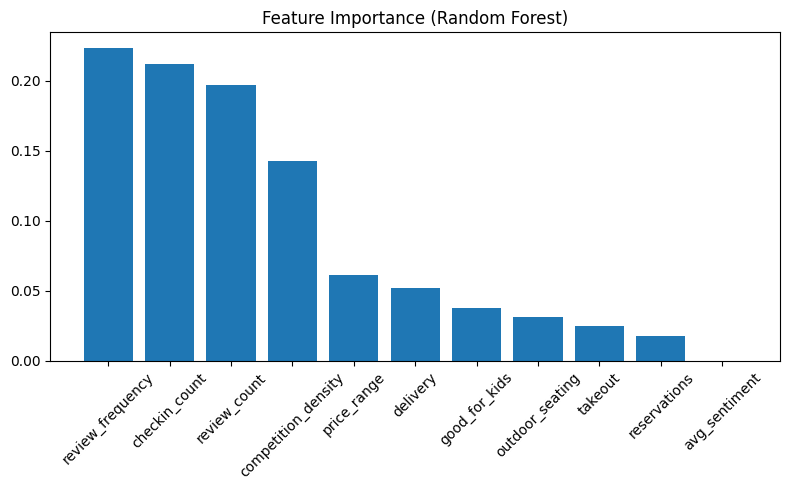

In [19]:
# ==============================
# 8. Feature Importance
# ==============================
importances = rf.feature_importances_
feature_names = X.columns

# Sort
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

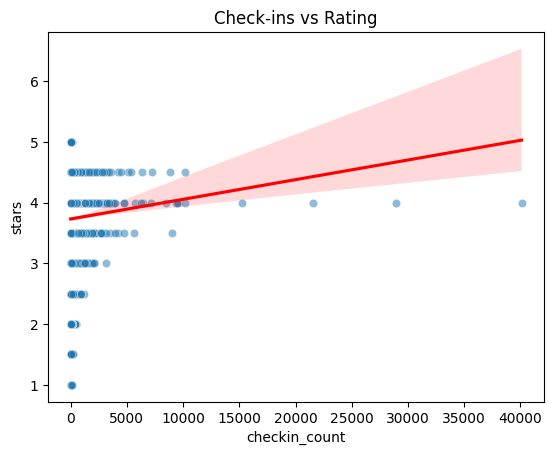

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='checkin_count', y='stars', data=df, alpha=0.5)
sns.regplot(x='checkin_count', y='stars', data=df, scatter=False, color='red')

plt.title("Check-ins vs Rating")
plt.show()